In [1]:
import sys
sys.path.append('..')

import yaml
import datetime as dt
import pandas as pd
import numpy as np
from decimal import Decimal
import quantstats as qs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests

from src.strategies.bollinger import DynamicMeanReversionStrategy
from src.strategies.zscore import DynamicZScoreStrategy
from src.strategies.kalman import KalmanZScoreStrategy
from src.engine.backtest import PairsBacktest
from src.engine.selector import StatisticalAutoSelector
from src.utils.metrics import evaluate_stationarity_regimes, apply_volatility_position_sizing, compare_strategy_statistics

import warnings
warnings.filterwarnings("ignore")

# Load Settings
with open('../config/settings.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# SETUP DATE SPLIT (15 Calendar Years: 70% Train / 30% Test)
split_ratio = config['backtest']['split_ratio']
lookback_years = config['backtest']['lookback_years']
total_calendar_days = int(lookback_years * 365.25)

end_date = pd.to_datetime(config['backtest']['end_date']).date()
start_date = end_date - pd.Timedelta(days=total_calendar_days)
train_days = int(total_calendar_days * split_ratio)
end_date_train = start_date + pd.Timedelta(days=train_days)
start_date_test = end_date_train + pd.Timedelta(days=1)

t_cost = config['backtest']['transaction_cost']
is_compounding = config['backtest']['compounding']
metric_to_use = config['backtest']['target_metric']

ticker_x = config['single_pair']['ticker_x']
ticker_y = config['single_pair']['ticker_y']

strategy_name_BB = config['strategy_names']['bollinger']
strategy_name_ZS = config['strategy_names']['zscore']
strategy_name_KF = config['strategy_names']['kalman']

print(f"[*] Optimization Target Metric set to: {metric_to_use.upper()}")
print(f"[*] Running simulation for {ticker_y} vs {ticker_x}")


[*] Optimization Target Metric set to: SHARPE_RATIO
[*] Running simulation for ITSA3.SA vs ITUB3.SA


--- Downloading and Testing Training Data (In-Sample) ---
**************************************************
--- Downloading and Testing Testing Data (Out-of-Sample) ---
**************************************************
--- Starting Optimization on Train Set (1500 models) ---

 Best Hyperparameters Identified (Target: sharpe_ratio): {'ols_window': 120, 'num_std': 1.29, 'stop_mult': None, 'ma_window': 'dynamic', 'train_return': 879.8425151080065, 'target_optimization_metric': 2.183966358861132}

--- Starting Out-of-Sample Validation (With Continuous Warmup) ---


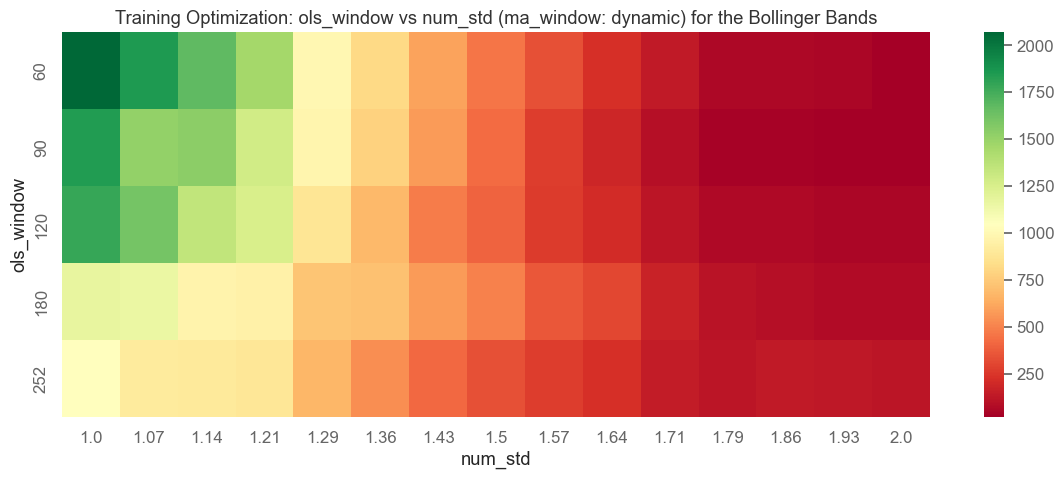

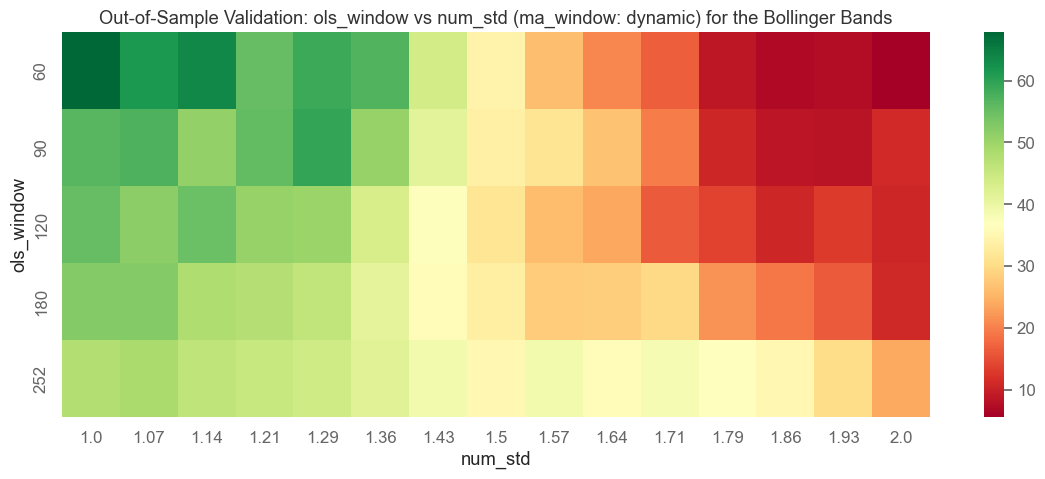


 IS vs OOS HYPERPARAMETER GRID CORRELATION - Bollinger Bands
 ma_window: [dynamic]
   -> Pearson (Linear): 0.8311
   -> Spearman (Rank):  0.8456
   -> Status: EXCELLENT
------------------------------------------------------------
 ma_window: [15]
   -> Pearson (Linear): 0.7071
   -> Spearman (Rank):  0.7504
   -> Status: EXCELLENT
------------------------------------------------------------
 ma_window: [20]
   -> Pearson (Linear): 0.8157
   -> Spearman (Rank):  0.8371
   -> Status: EXCELLENT
------------------------------------------------------------
 ma_window: [30]
   -> Pearson (Linear): 0.7622
   -> Spearman (Rank):  0.7450
   -> Status: EXCELLENT
------------------------------------------------------------

 Evaluating In-Sample Regimes for ITUB3.SA x ITSA3.SA

=== Performance by Stationarity Regime [COMPOUNDING (Reinvested)] ===
[STATIONARY REGIME (ADF p-value < 0.10)]
 Total Regime Days:   1061
 Active Trading Days: 619
 Cumulative Return:   270.94%
 Annualized Return:   36.53

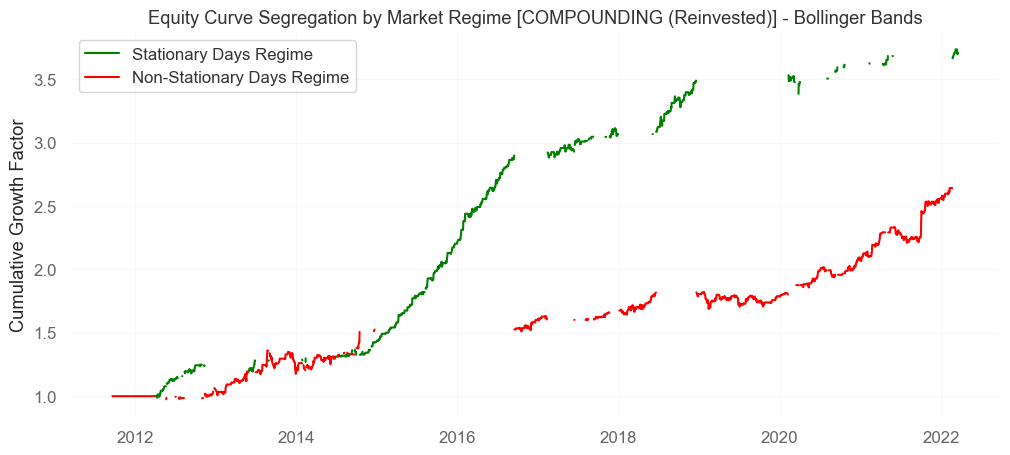


 Evaluating Out-of-Sample Regimes for ITUB3.SA x ITSA3.SA

=== Performance by Stationarity Regime [COMPOUNDING (Reinvested)] ===
[STATIONARY REGIME (ADF p-value < 0.10)]
 Total Regime Days:   338
 Active Trading Days: 207
 Cumulative Return:   18.54%
 Annualized Return:   13.52%
 Annualized Vol:      4.38%
 Sharpe Ratio:        2.92

[NON-STATIONARY REGIME (ADF p-value >= 0.10)]
 Total Regime Days:   786
 Active Trading Days: 554
 Cumulative Return:   26.81%
 Annualized Return:   7.91%
 Annualized Vol:      5.58%
 Sharpe Ratio:        1.39


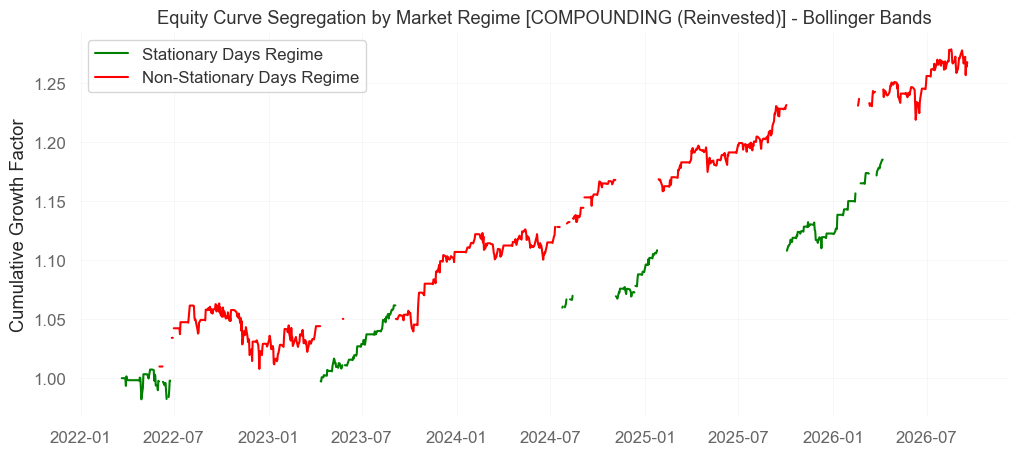

In [2]:
# ==============================================================================
# 1. HYPERPARAMETER GRID FOR BOLLINGER BANDS STRATEGY
# ==============================================================================
windows_grid = config['grids']['bollinger']['ols_windows']
bollinger_param_grid = {
    'num_std': [round(x, 2) for x in np.linspace(1.0, 2.0, 15)],
    'stop_mult': config['grids']['bollinger']['stop_mult'],
    'ma_window': config['grids']['bollinger']['ma_window']
}

# ==============================================================================
# 2. INITIALIZE AND EXECUTE MODULAR BACKTEST
# ==============================================================================
backtest = PairsBacktest(
    ticker_x=ticker_x,
    ticker_y=ticker_y,
    start_date=str(start_date),
    end_date_train=str(end_date_train),
    start_date_test=str(start_date_test),
    end_date=str(end_date),
    strategy_cls=DynamicMeanReversionStrategy,
    strategy_param_grid=bollinger_param_grid,
    ols_windows_to_test=windows_grid,
    show_heatmaps=True,
    transaction_cost=t_cost,
    compounding=is_compounding,  
    target_metric=metric_to_use,
    strategy_name=strategy_name_BB
)

final_train_df, final_test_df = backtest.execute_pipeline()

if final_train_df is not None and final_test_df is not None:
    print(f"\n Evaluating In-Sample Regimes for {ticker_x} x {ticker_y}")
    evaluate_stationarity_regimes(final_train_df, strategy_name_BB, is_compounding)

    print(f"\n Evaluating Out-of-Sample Regimes for {ticker_x} x {ticker_y}")
    evaluate_stationarity_regimes(final_test_df, strategy_name_BB, is_compounding)


In [3]:
strategy_returns_bb = final_test_df['net_strategy_returns'].fillna(0.0)
strategy_returns_bb.index = pd.to_datetime(strategy_returns_bb.index)

benchmark_returns = final_test_df[ticker_x].pct_change().fillna(0.0)
benchmark_returns.index = pd.to_datetime(benchmark_returns.index)

qs.reports.html(
    returns=strategy_returns_bb,
    benchmark=benchmark_returns,
    output='strategy_performance_report_BB_Strategy.html', 
    title=f'Pairs Trading Strategy - Out-of-Sample - {strategy_name_BB}',
    match_dates=True
)


ITUB3.SA Benchmark Volatility: 0.2849 (28.49%)


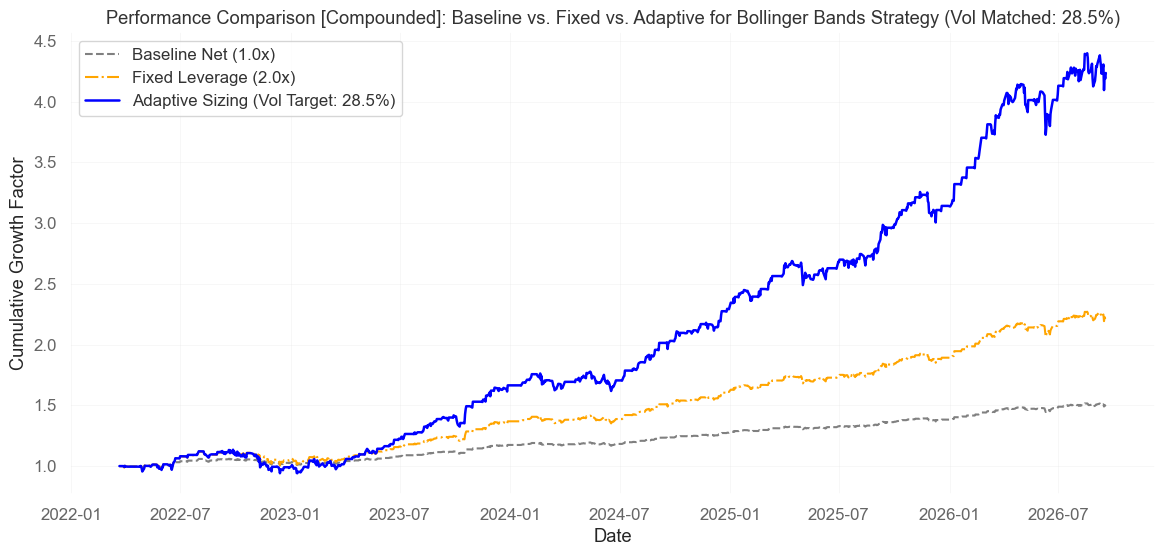

 📊 LEVERAGE: DYNAMIC vs FIXED | MODE: COMPOUNDED
 Baseline (1.0x)   Net:   50.32% | Vol:   5.25% | Sharpe:  1.77
 Fixed (2.0x)      Net:  123.17% | Vol:  10.50% | Sharpe:  1.77
 Adaptive (Vol)    Net:  323.61% | Vol:  18.41% | Sharpe:  1.85



In [4]:
benchmark_returns_train = final_train_df[ticker_x].pct_change().dropna()
rolling_benchmark_vol = benchmark_returns_train.rolling(window=20, min_periods=2).std(ddof=1) * np.sqrt(252)
benchmark_vol_target = rolling_benchmark_vol.mean()
benchmark_vol_decimal = Decimal(str(benchmark_vol_target)).quantize(Decimal('0.0001'))

print(f"{ticker_x} Benchmark Volatility: {benchmark_vol_decimal} ({float(benchmark_vol_decimal) * 100:.2f}%)")

df_alavancado_oos = apply_volatility_position_sizing(
    strategy_df=final_test_df,
    vol_lookback=20,
    target_vol_annualized=float(benchmark_vol_decimal),
    mode='inverse',
    min_multiplier=1.00,
    max_multiplier=4.00,
    fixed_leverage=2.00,
    budget_neutral=False,
    title=f'{strategy_name_BB} Strategy (Vol Matched: {benchmark_vol_target*100:.1f}%)',
    compounding=is_compounding
)


--- Downloading and Testing Training Data (In-Sample) ---
**************************************************
--- Downloading and Testing Testing Data (Out-of-Sample) ---
**************************************************
--- Starting Optimization on Train Set (2100 models) ---

 Best Hyperparameters Identified (Target: sharpe_ratio): {'ols_window': 120, 'entry_z': 1.0, 'exit_z': 0.5, 'stop_loss_z': None, 'lookback_window': 'dynamic', 'train_return': 1796.7905433318588, 'target_optimization_metric': 2.7337377578162143}

--- Starting Out-of-Sample Validation (With Continuous Warmup) ---


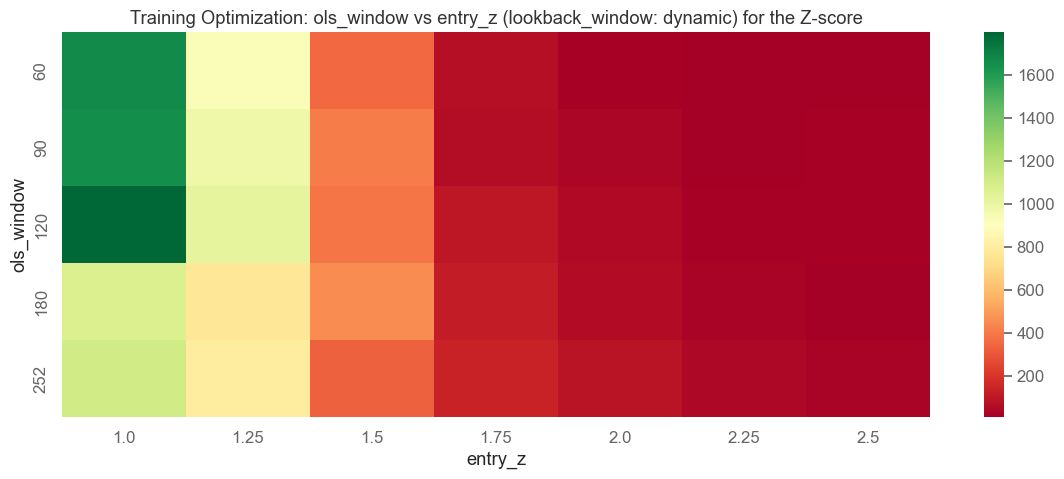

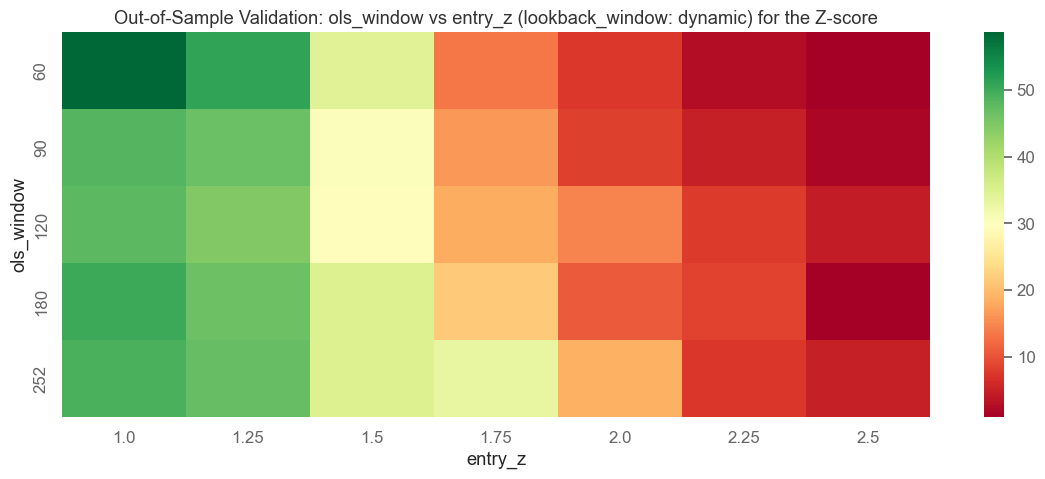


 IS vs OOS HYPERPARAMETER GRID CORRELATION - Z-score
 lookback_window: [dynamic]
   -> Pearson (Linear): 0.8916
   -> Spearman (Rank):  0.9667
   -> Status: EXCELLENT
------------------------------------------------------------
 lookback_window: [15]
   -> Pearson (Linear): 0.8546
   -> Spearman (Rank):  0.9478
   -> Status: EXCELLENT
------------------------------------------------------------
 lookback_window: [20]
   -> Pearson (Linear): 0.8771
   -> Spearman (Rank):  0.9136
   -> Status: EXCELLENT
------------------------------------------------------------
 lookback_window: [30]
   -> Pearson (Linear): 0.8661
   -> Spearman (Rank):  0.9167
   -> Status: EXCELLENT
------------------------------------------------------------

 EVALUATING IN-SAMPLE REGIMES - ITUB3.SA x ITSA3.SA

=== Performance by Stationarity Regime [COMPOUNDING (Reinvested)] ===
[STATIONARY REGIME (ADF p-value < 0.10)]
 Total Regime Days:   1061
 Active Trading Days: 725
 Cumulative Return:   424.18%
 Annualized R

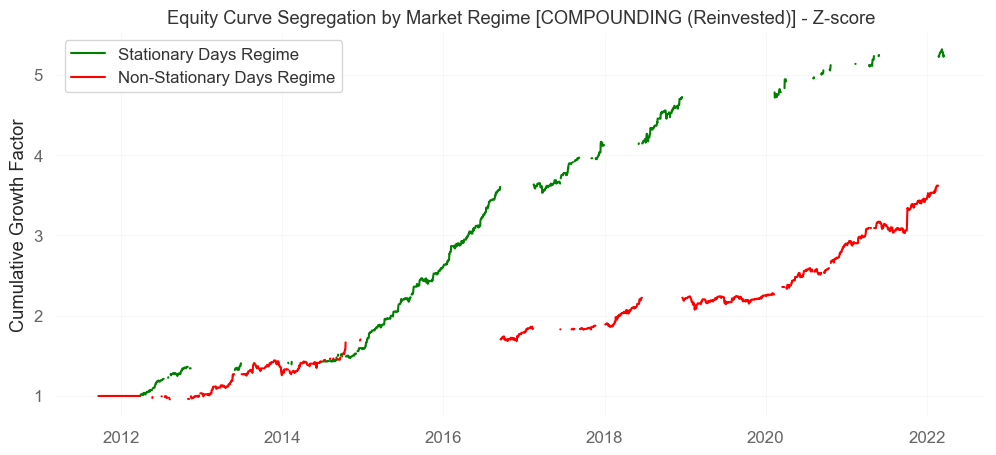


 EVALUATING OUT-OF-SAMPLE REGIMES - ITUB3.SA x ITSA3.SA

=== Performance by Stationarity Regime [COMPOUNDING (Reinvested)] ===
[STATIONARY REGIME (ADF p-value < 0.10)]
 Total Regime Days:   338
 Active Trading Days: 238
 Cumulative Return:   14.71%
 Annualized Return:   10.78%
 Annualized Vol:      4.83%
 Sharpe Ratio:        2.15

[NON-STATIONARY REGIME (ADF p-value >= 0.10)]
 Total Regime Days:   786
 Active Trading Days: 552
 Cumulative Return:   28.77%
 Annualized Return:   8.44%
 Annualized Vol:      5.41%
 Sharpe Ratio:        1.52


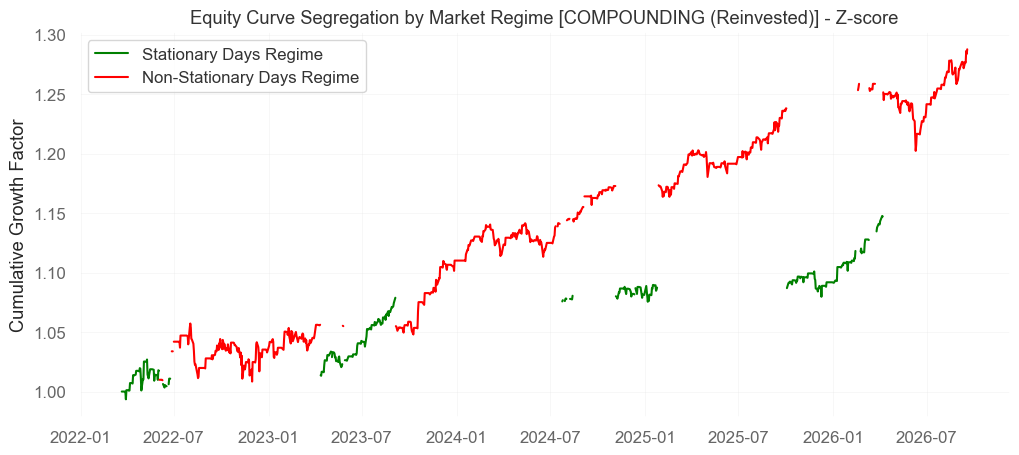

In [5]:
# ==============================================================================
# 1. HYPERPARAMETER GRID FOR Z-SCORE STRATEGY
# ==============================================================================
ols_windows_grid = config['grids']['zscore']['ols_windows']
zscore_param_grid = {
    'entry_z': [1, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5],
    'exit_z': config['grids']['zscore']['exit_z'],
    'stop_loss_z': config['grids']['zscore']['stop_loss_z'],
    'lookback_window': config['grids']['zscore']['lookback_window']
}

# ==============================================================================
# 2. INITIALIZE AND EXECUTE MODULAR BACKTEST
# ==============================================================================
zscore_backtest = PairsBacktest(
    ticker_x=ticker_x,
    ticker_y=ticker_y,
    start_date=str(start_date),
    end_date_train=str(end_date_train),
    start_date_test=str(start_date_test),
    end_date=str(end_date),
    strategy_cls=DynamicZScoreStrategy,
    strategy_param_grid=zscore_param_grid,
    ols_windows_to_test=ols_windows_grid,
    show_heatmaps=True,
    transaction_cost=t_cost,
    compounding=is_compounding,
    target_metric=metric_to_use,
    strategy_name=strategy_name_ZS
)

zscore_train_df, zscore_test_df = zscore_backtest.execute_pipeline()

if zscore_train_df is not None:
    print(f"\n EVALUATING IN-SAMPLE REGIMES - {ticker_x} x {ticker_y}")
    evaluate_stationarity_regimes(zscore_train_df, strategy_name_ZS, is_compounding)

if zscore_test_df is not None:
    print(f"\n EVALUATING OUT-OF-SAMPLE REGIMES - {ticker_x} x {ticker_y}")
    evaluate_stationarity_regimes(zscore_test_df, strategy_name_ZS, is_compounding)


In [6]:
strategy_returns_Zscore = zscore_test_df['net_strategy_returns'].fillna(0.0)
strategy_returns_Zscore.index = pd.to_datetime(strategy_returns_Zscore.index)

benchmark_returns = zscore_test_df[ticker_x].pct_change().fillna(0.0)
benchmark_returns.index = pd.to_datetime(benchmark_returns.index)

qs.reports.html(
    returns=strategy_returns_Zscore,
    benchmark=benchmark_returns,
    output='strategy_performance_report_Zscore_Strategy.html', 
    title=f'Pairs Trading Strategy - Out-of-Sample - {strategy_name_ZS}',
    match_dates=True
)


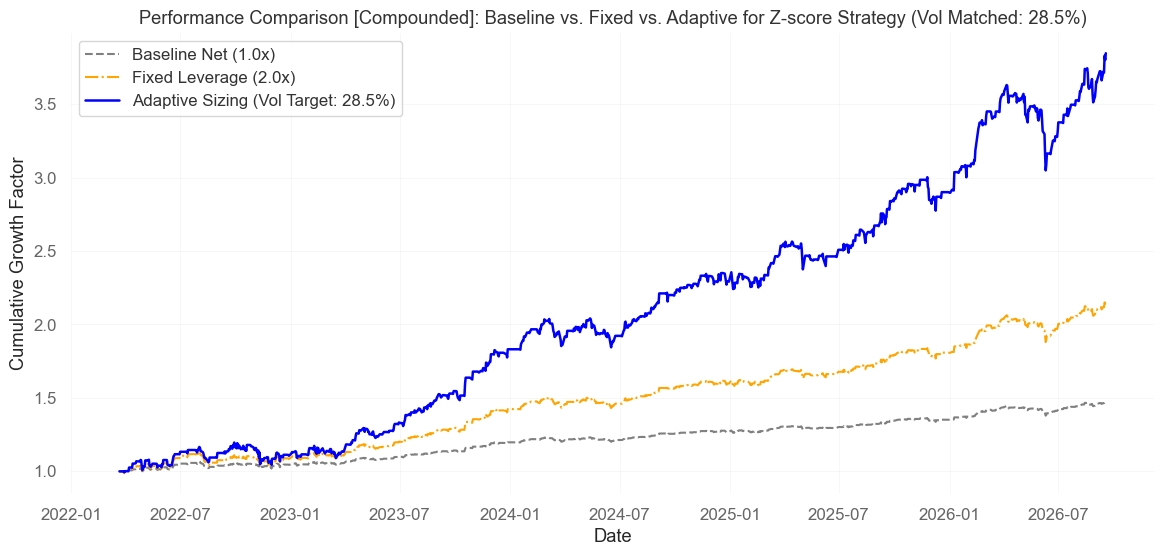

 📊 LEVERAGE: DYNAMIC vs FIXED | MODE: COMPOUNDED
 Baseline (1.0x)   Net:   47.71% | Vol:   5.24% | Sharpe:  1.70
 Fixed (2.0x)      Net:  115.51% | Vol:  10.48% | Sharpe:  1.70
 Adaptive (Vol)    Net:  284.61% | Vol:  18.25% | Sharpe:  1.75



In [7]:
df_Zscore_alavancado_oos = apply_volatility_position_sizing(
    strategy_df=zscore_test_df,
    vol_lookback=20,
    target_vol_annualized=float(benchmark_vol_decimal),
    mode='inverse',
    min_multiplier=1.00,
    max_multiplier=4.00,
    fixed_leverage=2.00,
    budget_neutral=False,
    title=f'{strategy_name_ZS} Strategy (Vol Matched: {benchmark_vol_target*100:.1f}%)',
    compounding=is_compounding
)


--- Downloading and Testing Training Data (In-Sample) ---
**************************************************
--- Downloading and Testing Testing Data (Out-of-Sample) ---
**************************************************
--- Starting Optimization on Train Set (420 models) ---

 Best Hyperparameters Identified (Target: sharpe_ratio): {'ols_window': 'Kalman', 'entry_z': 1.25, 'exit_z': 0.5, 'stop_loss_z': 3.5, 'delta': 1e-05, 'obs_variance': 0.001, 'train_return': 916.4436322698258, 'target_optimization_metric': 2.2987640469263413}

--- Starting Out-of-Sample Validation (With Continuous Warmup) ---


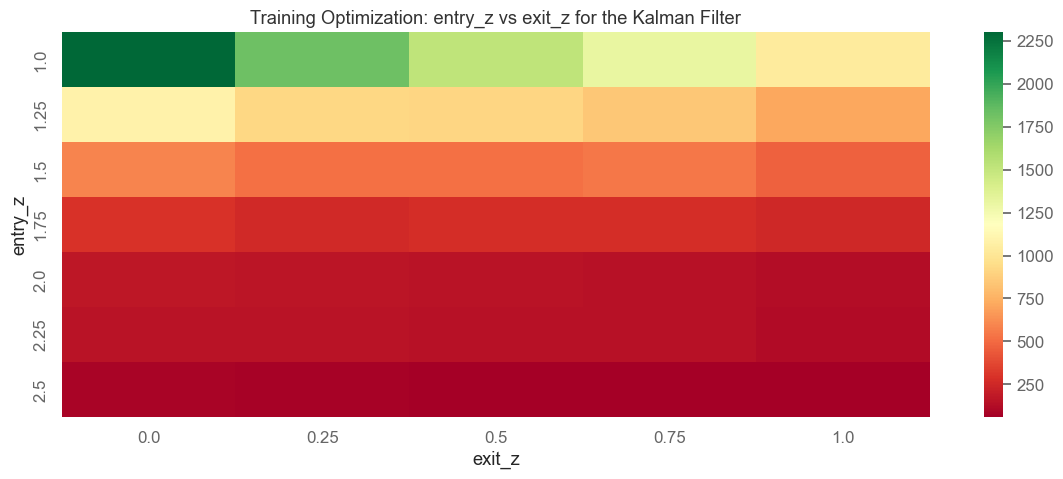

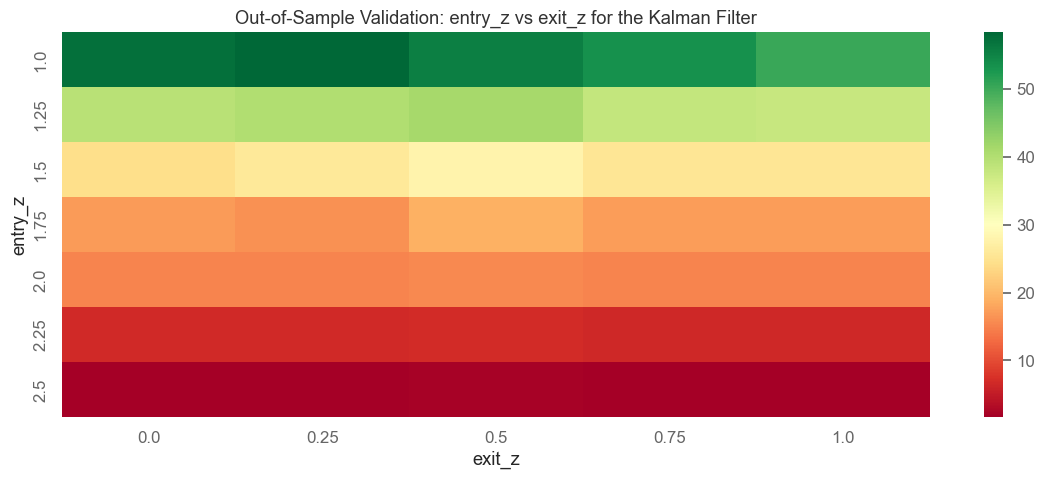


 IS vs OOS HYPERPARAMETER GRID CORRELATION - Kalman Filter
 delta: [1e-05]
   -> Pearson (Linear): 0.9300
   -> Spearman (Rank):  0.9682
   -> Status: EXCELLENT
------------------------------------------------------------
 delta: [0.0001]
   -> Pearson (Linear): 0.8673
   -> Spearman (Rank):  0.4464
   -> Status: WEAK
------------------------------------------------------------
 delta: [0.001]
   -> Pearson (Linear): nan
   -> Spearman (Rank):  nan
   -> Status: OVERFITTED
------------------------------------------------------------

 EVALUATING IN-SAMPLE REGIMES - ITUB3.SA x ITSA3.SA

=== Performance by Stationarity Regime [COMPOUNDING (Reinvested)] ===
[STATIONARY REGIME (ADF p-value < 0.10)]
 Total Regime Days:   2512
 Active Trading Days: 847
 Cumulative Return:   809.00%
 Annualized Return:   24.78%
 Annualized Vol:      9.97%
 Sharpe Ratio:        2.27

[NON-STATIONARY REGIME (ADF p-value >= 0.10)]
 Total Regime Days:   89
 Active Trading Days: 33
 Cumulative Return:   11.82%
 A

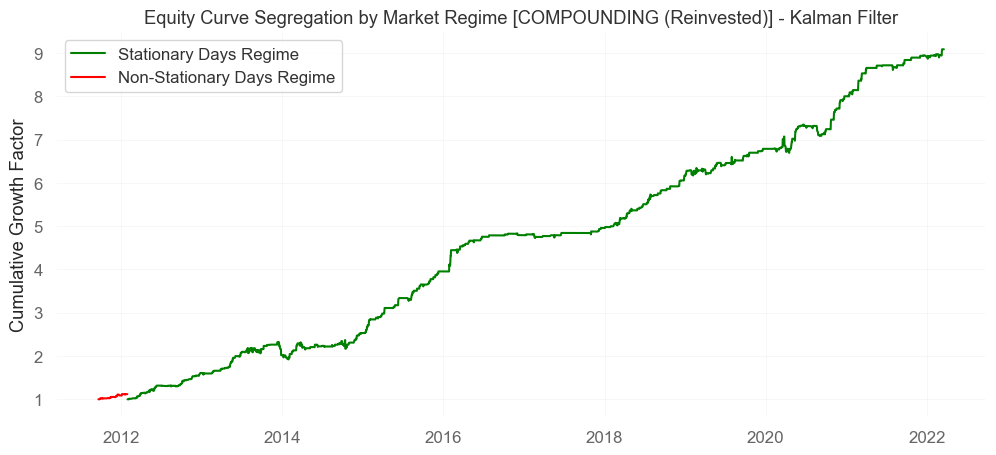


 EVALUATING OUT-OF-SAMPLE REGIMES - ITUB3.SA x ITSA3.SA

=== Performance by Stationarity Regime [COMPOUNDING (Reinvested)] ===
[STATIONARY REGIME (ADF p-value < 0.10)]
 Total Regime Days:   1124
 Active Trading Days: 173
 Cumulative Return:   41.20%
 Annualized Return:   8.04%
 Annualized Vol:      3.00%
 Sharpe Ratio:        2.59

[NON-STATIONARY REGIME (ADF p-value >= 0.10)]
 Total Regime Days:   0
 Active Trading Days: 0
 Cumulative Return:   0.00%
 Annualized Return:   0.00%
 Annualized Vol:      nan%
 Sharpe Ratio:        0.00


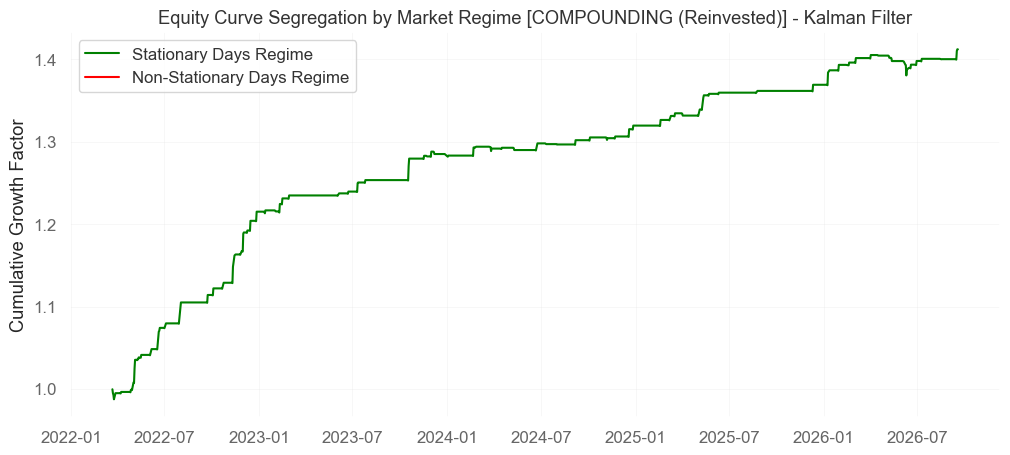

In [8]:
# ==============================================================================
# 1. HYPERPARAMETER GRID FOR KALMAN FILTER STRATEGY
# ==============================================================================
kalman_param_grid = {
    'entry_z': [1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5],
    'exit_z': config['grids']['kalman']['exit_z'],
    'stop_loss_z': config['grids']['kalman']['stop_loss_z'],
    'delta': config['grids']['kalman']['delta'],        
    'obs_variance': config['grids']['kalman']['obs_variance']        
}

# ==============================================================================
# 2. INITIALIZE AND EXECUTE MODULAR BACKTEST
# ==============================================================================
kalman_backtest = PairsBacktest(
    ticker_x=ticker_x,
    ticker_y=ticker_y,
    start_date=str(start_date),
    end_date_train=str(end_date_train),
    start_date_test=str(start_date_test),
    end_date=str(end_date),
    strategy_cls=KalmanZScoreStrategy,
    strategy_param_grid=kalman_param_grid,
    show_heatmaps=True,
    transaction_cost=t_cost,
    compounding=is_compounding,
    target_metric=metric_to_use,
    strategy_name=strategy_name_KF
)

kalman_train_df, kalman_test_df = kalman_backtest.execute_pipeline()

if kalman_train_df is not None:
    print(f"\n EVALUATING IN-SAMPLE REGIMES - {ticker_x} x {ticker_y}")
    evaluate_stationarity_regimes(kalman_train_df, strategy_name_KF, is_compounding)

if kalman_test_df is not None:
    print(f"\n EVALUATING OUT-OF-SAMPLE REGIMES - {ticker_x} x {ticker_y}")
    evaluate_stationarity_regimes(kalman_test_df, strategy_name_KF, is_compounding)


In [14]:
strategy_returns = kalman_test_df['net_strategy_returns'].fillna(0.0)
strategy_returns.index = pd.to_datetime(strategy_returns.index)

# BENCHMARK LOGIC: FETCHING CDI (BRAZILIAN RISK-FREE RATE) FROM BCB API
start_dt = strategy_returns.index.min().strftime('%d/%m/%Y')
end_dt = strategy_returns.index.max().strftime('%d/%m/%Y')
bcb_url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados?formato=json&dataInicial={start_dt}&dataFinal={end_dt}"

try:
    response = requests.get(bcb_url)
    response.raise_for_status()
    cdi_data = response.json()
    
    df_cdi = pd.DataFrame(cdi_data)
    df_cdi['data'] = pd.to_datetime(df_cdi['data'], format='%d/%m/%Y')
    df_cdi.set_index('data', inplace=True)
    df_cdi['valor'] = df_cdi['valor'].astype(float) / 100.0
    
    benchmark_returns = df_cdi['valor'].reindex(strategy_returns.index).fillna(0.0)
    benchmark_returns.name = 'CDI'

except Exception as e:
    print(f"Error fetching CDI data: {e}")
    benchmark_returns = pd.Series(0.0, index=strategy_returns.index, name='CDI')

qs.reports.html(
    returns=strategy_returns,
    benchmark=benchmark_returns,
    output='strategy_performance_report_Kalman_Strategy_CDI.html', 
    title=f'Pairs Trading Strategy - Out-of-Sample - {strategy_name_KF} (CDI Benchmark)',
    match_dates=True
)


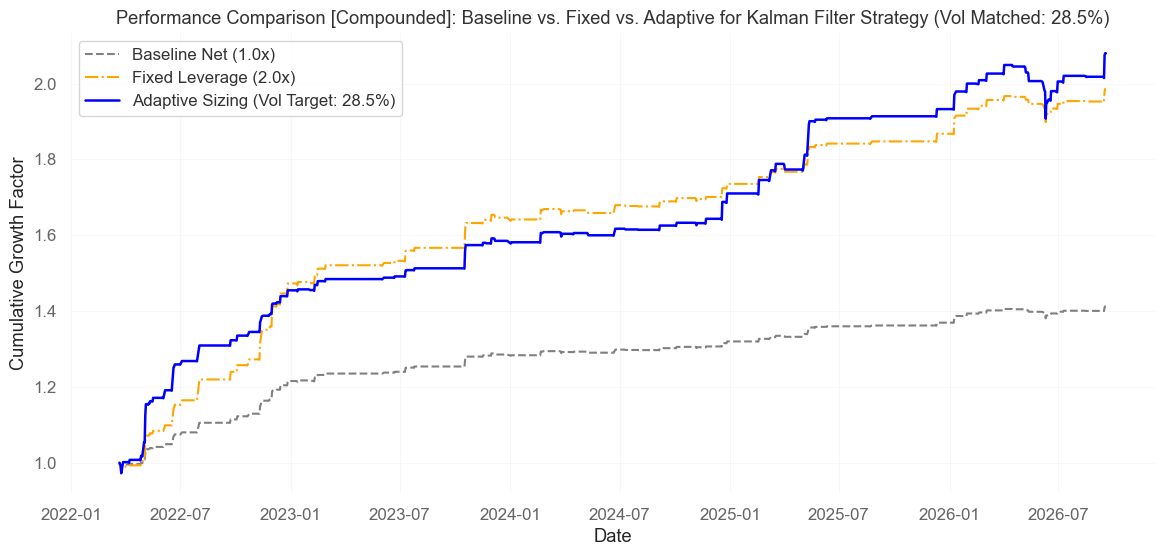

 📊 LEVERAGE: DYNAMIC vs FIXED | MODE: COMPOUNDED
 Baseline (1.0x)   Net:   41.20% | Vol:   3.00% | Sharpe:  2.59
 Fixed (2.0x)      Net:   98.58% | Vol:   6.00% | Sharpe:  2.59
 Adaptive (Vol)    Net:  107.98% | Vol:   7.42% | Sharpe:  2.25



In [10]:
df_kalman_alavancado_oos = apply_volatility_position_sizing(
    strategy_df=kalman_test_df,
    vol_lookback=20,
    target_vol_annualized=float(benchmark_vol_decimal),
    mode='inverse',
    min_multiplier=1.00,
    max_multiplier=4.00,
    fixed_leverage=2.00,
    budget_neutral=False,
    title=f'{strategy_name_KF} Strategy (Vol Matched: {benchmark_vol_target*100:.1f}%)',
    compounding=is_compounding
)


In [11]:
# =============================================================================
# 1. DYNAMIC META-MODEL CONFIGURATION
# =============================================================================
optimized_strategies_config = {
    'Bollinger_Bands': (DynamicMeanReversionStrategy, backtest.best_params),
    'Dynamic_ZScore':  (DynamicZScoreStrategy, zscore_backtest.best_params),
    'Kalman_Filter':   (KalmanZScoreStrategy, kalman_backtest.best_params)
}

print("=" * 75)
print(" DYNAMIC META-MODEL CONFIGURATION LOADED")
print("=" * 75)
for strat, (cls, p_dict) in optimized_strategies_config.items():
    print(f" {strat:<18}: {p_dict}")

# =============================================================================
# 2. DATASET CONSOLIDATION AND META-MODEL INITIALIZATION
# =============================================================================
df_full_market = pd.concat([backtest.df_train, backtest.df_test]).copy()

meta_model = StatisticalAutoSelector(
    df_full=df_full_market,
    test_start_date=start_date_test,  
    ticker_x=ticker_x,
    ticker_y=ticker_y,
    strategies_config=optimized_strategies_config,
    lookback_days=90,
    step_days=21,
    transaction_cost=t_cost
)

# =============================================================================
# 3. EXECUTE STATISTICAL AUTO-SELECTOR
# =============================================================================
df_meta_results = meta_model.run()

print("=" * 75)
print(" DYNAMIC STRATEGY SELECTION (STATISTICAL REGIME TRANSITIONS)")
print("=" * 75)
print("Strategy utilization across the Out-of-Sample period (Days):")
print(df_meta_results['selected_strategy'].value_counts())


 DYNAMIC META-MODEL CONFIGURATION LOADED
 Bollinger_Bands   : {'ols_window': 120, 'num_std': 1.29, 'stop_mult': None, 'ma_window': 'dynamic', 'train_return': 879.8425151080065, 'target_optimization_metric': 2.183966358861132}
 Dynamic_ZScore    : {'ols_window': 120, 'entry_z': 1.0, 'exit_z': 0.5, 'stop_loss_z': None, 'lookback_window': 'dynamic', 'train_return': 1796.7905433318588, 'target_optimization_metric': 2.7337377578162143}
 Kalman_Filter     : {'ols_window': 'Kalman', 'entry_z': 1.25, 'exit_z': 0.5, 'stop_loss_z': 3.5, 'delta': 1e-05, 'obs_variance': 0.001, 'train_return': 916.4436322698258, 'target_optimization_metric': 2.2987640469263413}
 DYNAMIC STRATEGY SELECTION (STATISTICAL REGIME TRANSITIONS)
Strategy utilization across the Out-of-Sample period (Days):
selected_strategy
Kalman_Filter      725
Bollinger_Bands    357
Dynamic_ZScore      42
Name: count, dtype: int64



 OUT-OF-SAMPLE METRICS COMPARISON (META-MODEL VS STANDALONE)
 Meta Model           | Return:   48.35% | Vol:   3.73% | Sharpe:  2.39
 Bollinger Bands      | Return:   50.61% | Vol:   5.26% | Sharpe:  1.77
 Dynamic ZScore       | Return:   47.63% | Vol:   5.26% | Sharpe:  1.69
 Kalman Filter        | Return:   41.20% | Vol:   3.00% | Sharpe:  2.59


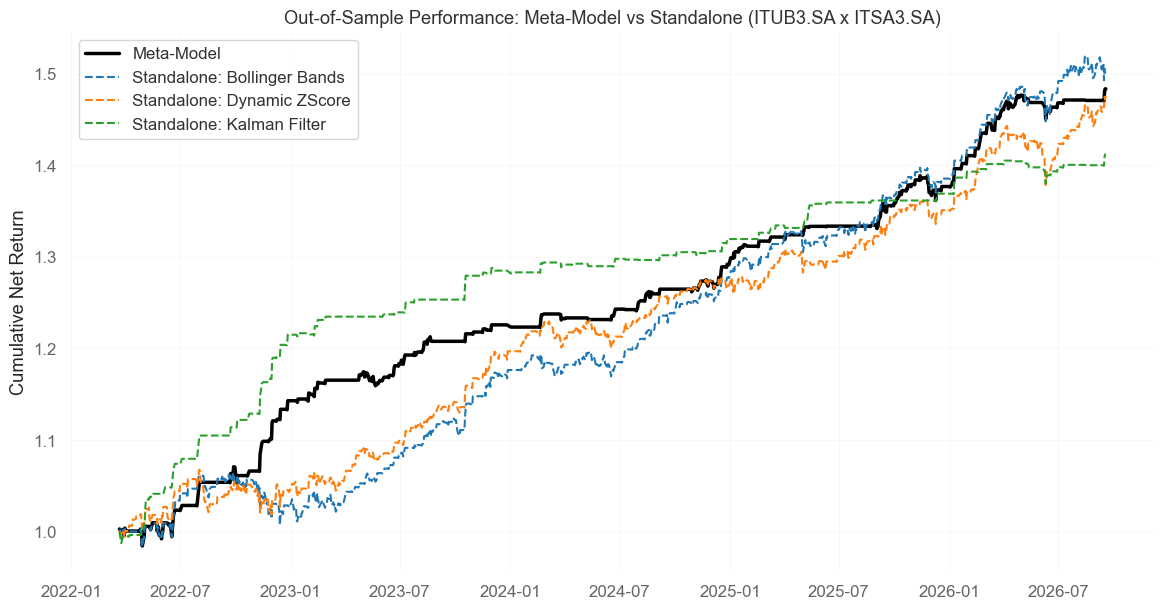

 STRATEGY UTILIZATION RATE (OUT-OF-SAMPLE)
 Kalman_Filter       :  64.5% of trading days
 Bollinger_Bands     :  31.8% of trading days
 Dynamic_ZScore      :   3.7% of trading days


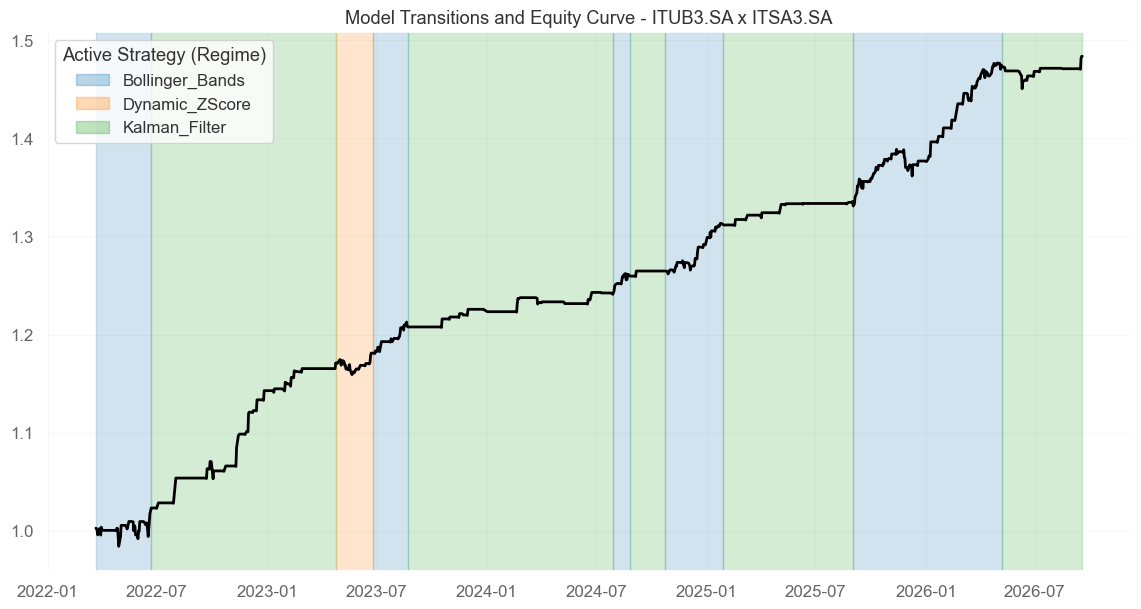

In [15]:
# =============================================================================
# 4. STANDALONE STRATEGIES OUT-OF-SAMPLE EXECUTION (FOR COMPARISON)
# =============================================================================
from src.engine.analyzer import RollingSpreadAnalyzer
comparison_returns = {}
comparison_returns['Meta_Model'] = df_meta_results['net_strategy_returns'].fillna(0.0)

for strat_name, (StratClass, params) in optimized_strategies_config.items():
    metrics_to_ignore = ['train_return', 'test_return', 'target_optimization_metric', 'recovery_factor', 'sharpe_ratio', 'profit_factor', 'trade_count', 'decision_score']
    strat_params = {k: v for k, v in params.items() if k not in metrics_to_ignore and k != 'ols_window'}
    strat_params['compounding'] = False
    
    if issubclass(StratClass, KalmanZScoreStrategy):
        strat_instance = StratClass(
            df_full_market.copy(), ticker_x, ticker_y, transaction_cost=t_cost, **strat_params
        )
    else:
        ols_w = params.get('ols_window', 90)
        analyzer = RollingSpreadAnalyzer(df_full_market.copy(), ticker_x, ticker_y, window=ols_w)
        df_analyzed = analyzer.run_analysis()
        strat_instance = StratClass(
            df_analyzed, ticker_x, ticker_y, transaction_cost=t_cost, **strat_params
        )
        
    oos_daily_returns = strat_instance.df.loc[df_meta_results.index, 'net_strategy_returns'].fillna(0.0)
    comparison_returns[strat_name] = oos_daily_returns

df_comparison = pd.DataFrame(comparison_returns)

# =============================================================================
# 5. PERFORMANCE METRICS AND VISUALIZATION
# =============================================================================
print("\n" + "=" * 83)
print(" OUT-OF-SAMPLE METRICS COMPARISON (META-MODEL VS STANDALONE)")
print("=" * 83)
for column in df_comparison.columns:
    daily_ret = df_comparison[column]
    net_cum_ret = ((daily_ret + 1.0).cumprod().iloc[-1] - 1.0) * 100.0
    ann_vol = daily_ret.std() * np.sqrt(252) * 100.0
    sharpe = (daily_ret.mean() * 252) / (daily_ret.std() * np.sqrt(252)) if ann_vol > 0 else 0.0
    display_name = column.replace('_', ' ')
    print(f" {display_name:<20} | Return: {net_cum_ret:>7.2f}% | Vol: {ann_vol:>6.2f}% | Sharpe: {sharpe:>5.2f}")

df_cumulative = (df_comparison + 1.0).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(df_cumulative.index, df_cumulative['Meta_Model'], label='Meta-Model', color='black', linewidth=2.5)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for idx, col in enumerate([c for c in df_comparison.columns if c != 'Meta_Model']):
    plt.plot(df_cumulative.index, df_cumulative[col], label=f"Standalone: {col.replace('_', ' ')}", color=colors[idx], linestyle='--')

plt.title(f'Out-of-Sample Performance: Meta-Model vs Standalone ({ticker_x} x {ticker_y})')
plt.ylabel('Cumulative Net Return')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# =============================================================================
# 6. STRATEGY UTILIZATION PLOT
# =============================================================================

print("=" * 75)
print(" STRATEGY UTILIZATION RATE (OUT-OF-SAMPLE)")
print("=" * 75)
usage_rates = df_meta_results['selected_strategy'].value_counts(normalize=True) * 100
for strat, rate in usage_rates.items():
    print(f" {strat:<20}: {rate:>5.1f}% of trading days")
print("=" * 75)

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df_meta_results.index, df_meta_results['cumulative_returns'], color='black', linewidth=2, label='Meta-Model Equity Curve')

strat_colors = {'Bollinger_Bands': '#1f77b4', 'Dynamic_ZScore': '#ff7f0e', 'Kalman_Filter': '#2ca02c', 'None (Cash)': '#d62728'}
initial_date_chart = df_meta_results.index[0]
current_strat = df_meta_results['selected_strategy'].iloc[0]

for date, row in df_meta_results.iterrows():
    strat = row['selected_strategy']
    if strat != current_strat:
        ax.axvspan(initial_date_chart, date, color=strat_colors.get(current_strat, 'gray'), alpha=0.2)
        initial_date_chart = date
        current_strat = strat

ax.axvspan(initial_date_chart, df_meta_results.index[-1], color=strat_colors.get(current_strat, 'gray'), alpha=0.2)
legend_patches = [mpatches.Patch(color=color, alpha=0.3, label=strat) for strat, color in strat_colors.items() if strat in df_meta_results['selected_strategy'].unique()]
ax.legend(handles=legend_patches, loc='upper left', title="Active Strategy (Regime)")
plt.title(f'Model Transitions and Equity Curve - {ticker_x} x {ticker_y}')
plt.grid(True, alpha=0.3)
plt.show()


In [18]:
# Compare Train Statistics
comparison_df_train, trade_logs_train = compare_strategy_statistics(
    dfs=[final_train_df, zscore_train_df, kalman_train_df],
    labels=[strategy_name_BB, strategy_name_ZS, strategy_name_KF],
    compounding=is_compounding,
    annualization_factor=252,
    risk_free_rate=0.0
)




STRATEGY COMPARISON — COMPOUNDED
----------------------------------------------------------------------------
Metric                        | Bollinger Bands |    Z-score | Kalman Filter
----------------------------------------------------------------------------
Start date                    |      2011-09-21 | 2011-09-21 |    2011-09-21
End date                      |      2022-03-18 | 2022-03-18 |    2022-03-18
Trading days                  |            2601 |       2601 |          2601
Period (months)               |          125.86 |     125.86 |        125.86
Period (years)                |           10.49 |      10.49 |         10.49
----------------------------------------------------------------------------
Gross return (%)              |         1165.24 |    2709.32 |       1254.37
Cost drag (%)                 |          285.40 |     912.53 |        337.93
Net return (%)                |          879.84 |    1796.79 |        916.44
Net CAGR (%)                  |           

In [19]:
# Compare Test Statistics
comparison_df_test, trade_logs_test = compare_strategy_statistics(
    dfs=[final_test_df, zscore_test_df, kalman_test_df],
    labels=[strategy_name_BB, strategy_name_ZS, strategy_name_KF],
    compounding=is_compounding,
    annualization_factor=252,
    risk_free_rate=0.0
)


STRATEGY COMPARISON — COMPOUNDED
----------------------------------------------------------------------------
Metric                        | Bollinger Bands |    Z-score | Kalman Filter
----------------------------------------------------------------------------
Start date                    |      2022-03-22 | 2022-03-22 |    2022-03-22
End date                      |      2026-09-18 | 2026-09-18 |    2026-09-18
Trading days                  |            1124 |       1124 |          1124
Period (months)               |           53.91 |      53.91 |         53.91
Period (years)                |            4.49 |       4.49 |          4.49
----------------------------------------------------------------------------
Gross return (%)              |           68.48 |      75.35 |         51.35
Cost drag (%)                 |           18.17 |      27.64 |         10.14
Net return (%)                |           50.32 |      47.71 |         41.20
Net CAGR (%)                  |           